In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)

## 28/09/2026

## Regression

## California Housing Price Prediction

In [4]:
from sklearn.datasets import fetch_california_housing
# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target # Median house value in $100,000s
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

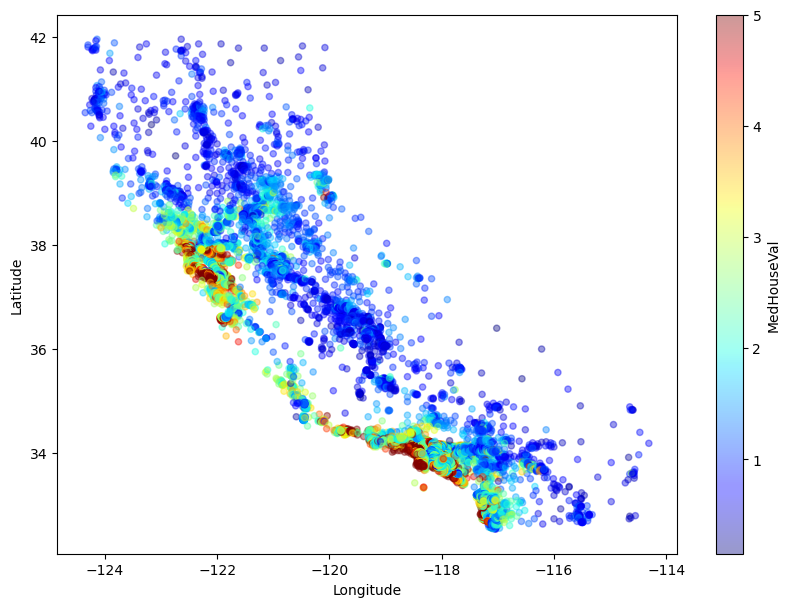

In [6]:
# Plot housing locations colored by median house value
california = fetch_california_housing()
housing_df = pd.DataFrame(california.data, columns=california.feature_names)
housing_df['MedHouseVal'] = california.target

housing_df.plot(
kind="scatter",
x="Longitude",
y="Latitude",
alpha=0.4,
c="MedHouseVal",
cmap=plt.get_cmap("jet"),
colorbar=True,
figsize=(10, 7),
)


plt.show()

In [7]:
# split and preprocess the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42
)

# Scale features
# StandardScaler scales features to have mean 0 and std 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Training a Regression Model, let's use linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Evaluate the Model
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
# (lower is better, 0 is perfect)

Mean Squared Error: 0.56


In [10]:
# The coefficient of determination or R^2

model.score(X_test_scaled, y_test)
# higher is better, 1 is perfect

0.575787706032451

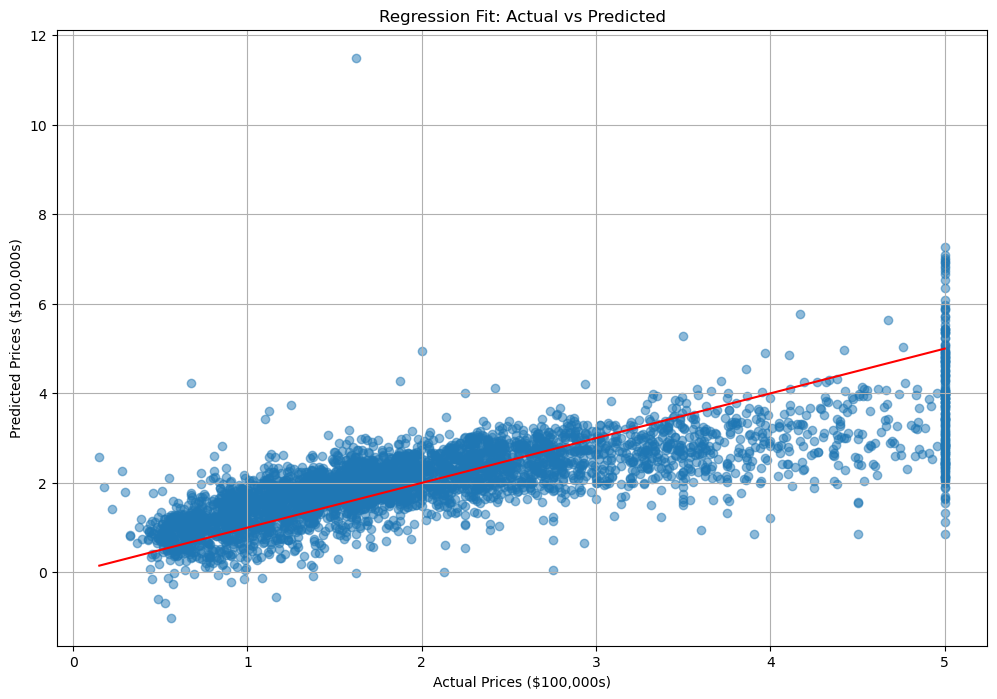

In [11]:
# Lets visualize: plot Actual vs Predicted (Regression Fit)
import matplotlib.pyplot as plt
# import seaborn as sns

plt.figure(figsize=(12, 8))
plt.scatter(x=y_test, y=y_pred, alpha=.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("Actual Prices ($100,000s)")
plt.ylabel("Predicted Prices ($100,000s)")
plt.title("Regression Fit: Actual vs Predicted")
plt.grid(True)
plt.show()

In [12]:
# using the first model, result should be the same

def predict_house_price2(MedInc, HouseAge, AveRooms, AveBedrms,
                        Population, AveOccup, Latitude, Longitude):
    
    # Prepare input as a 2D array (one row, 8 features)
    sample = [[MedInc, HouseAge, AveRooms, AveBedrms,
           Population, AveOccup, Latitude, Longitude]]

    sample = scaler.transform(sample)
    predicted_price = model.predict(sample)[0]
    return f"Estimated House Price: ${predicted_price * 100000:,.2f}"

In [13]:
predict_house_price2(MedInc=8.3, HouseAge=41.0, AveRooms=6.0, AveBedrms=1.0,
Population=980, AveOccup=2.5, Latitude=37.5, Longitude=-122.3)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Estimated House Price: $443,209.67'

In [14]:
predict_house_price2(MedInc=8.3, HouseAge=45.0, AveRooms=6.0, AveBedrms=1.0,
Population=780, AveOccup=2.5, Latitude=37.5, Longitude=-122.3)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Estimated House Price: $447,139.97'

## Let's use Pipleine

In [15]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
('scaler', StandardScaler()),
('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [18]:
# Evaluate the Model on the test data

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 0.56


In [19]:
pipeline.score(X_test, y_test)

0.575787706032451

In [20]:
X_test.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [21]:
# Let's create a Prediction Function that accepts 8 input values
# and returns the predicted house price in dollars.
def predict_house_price(MedInc, HouseAge, AveRooms, AveBedrms,
                        Population, AveOccup, Latitude, Longitude):
    # Prepare input as a 2D array (one row, 8 features)
    sample = pd.DataFrame({
        'MedInc': [MedInc],
        'HouseAge': [HouseAge],
        'AveRooms': [AveRooms],
        'AveBedrms': [AveBedrms],
        'Population': [Population],
        'AveOccup': [AveOccup],
        'Latitude': [Latitude],
        'Longitude': [Longitude]
})

    predicted_price = pipeline.predict(sample)[0]
    return f"Estimated House Price: ${predicted_price * 100_000:,.2f}"

In [22]:
predict_house_price(MedInc=8.3, HouseAge=41.0, AveRooms=6.0, AveBedrms=1.0,
                    Population=980, AveOccup=2.5, Latitude=37.5, Longitude=-122.3)

'Estimated House Price: $443,209.67'